RQ1

Topik apa saja yang mendominasi percakapan publik terkait MBG pada platform X?

RQ2

Apakah terdapat polarisasi opini antar komunitas pengguna?

RQ3
Siapa aktor paling berpengaruh dalam penyebaran narasi MBG?

#### Import data

In [ ]:
!pip install nlp-id
!pip install Sastrawi
!pip install gensim

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import ast
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from nlp_id.stopword import StopWord
from sklearn.decomposition import LatentDirichletAllocation
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
import networkx as nx
from tqdm import tqdm
from transformers import pipeline
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

In [ ]:
csv_path = "case2_dataset.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    url = "https://docs.google.com/spreadsheets/d/1WH7ik5qGtPKVwdhamQ-izULZn1lz82oK/export?format=csv&gid=1869848218"
    df = pd.read_csv(url)
    df.to_csv(csv_path, index=False)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10561 entries, 0 to 10560
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     10561 non-null  object 
 1   lang                     10561 non-null  object 
 2   source                   10561 non-null  object 
 3   user_id                  10561 non-null  object 
 4   hashtags                 10561 non-null  object 
 5   is_quote                 10561 non-null  bool   
 6   mentions                 10561 non-null  object 
 7   tweet_id                 10561 non-null  object 
 8   username                 10561 non-null  object 
 9   verified                 10561 non-null  bool   
 10  full_text                10561 non-null  object 
 11  created_at               10561 non-null  object 
 12  quoted_url               1386 non-null   object 
 13  view_count               10561 non-null  int64  
 14  quote_count           

### EDA

In [ ]:
print(df.shape)
df.head()

(10561, 32)


,date,lang,source,user_id,hashtags,is_quote,mentions,tweet_id,username,verified,...,quoted_tweet_id,quoted_username,user_created_at,user_description,in_reply_to_user_id,user_statuses_count,user_followers_count,user_following_count,in_reply_to_status_id,in_reply_to_screen_name
0,"45662,58063",in,dlvr.it,"1,6663E+18",[],False,[],"1,8759E+18",arinadotid,False,...,NaN,NaN,Wed Jun 07 04:40:18 +0000 2023,Media khas keislaman yang berjejaring dengan m...,NaN,5911.0,110.0,20.0,NaN,NaN
1,"45752,56706",in,Twitter Web App,"1,35691E+18","[""PenuhiGiziIndonesia"",""Indonesiaemas"",""AstaCi...",False,[],"1,90851E+18",ArifaNidya,False,...,NaN,NaN,Wed Feb 03 10:18:32 +0000 2021,make me special,NaN,5069.0,15.0,25.0,NaN,NaN
2,"45671,93193",in,Twitter for Android,553451866,[],False,"[{""name"":""Lambe Waras"",""user_id"":""2905814730"",...","1,87929E+18",ZainAris,False,...,NaN,NaN,Sat Apr 14 11:15:29 +0000 2012,Pemerhati sospol hukum dan ekonomi,2905814730,19762.0,701.0,1103.0,"1,87929E+18",abu_waras
3,"45715,64344",in,Twitter for Android,"1,30075E+18",[],False,"[{""name"":""Tanyarl 💚"",""user_id"":""13316505595189...","1,89513E+18",hereseans,False,...,NaN,NaN,Tue Sep 01 10:52:47 +0000 2020,INTJ,"1,75087E+18",20947.0,1977.0,2052.0,"1,89513E+18",HukumItb
4,"45946,96626",in,Twitter for Android,"1,91004E+18",[],False,[],"1,97896E+18",revirevii1,False,...,NaN,NaN,Wed Apr 09 18:43:39 +0000 2025,NaN,NaN,1198.0,1002.0,1116.0,NaN,NaN


In [ ]:
# Check missing value
missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "column": missing.index,
    "missing_count": missing.values,
    "missing_percentage": (missing.values / len(df))
})

missing_df

,column,missing_count,missing_percentage
0,quoted_url,9175,0.868762
1,quoted_username,9175,0.868762
2,quoted_tweet_id,9174,0.868668
3,quoted_text,9174,0.868668
4,in_reply_to_status_id,4958,0.469463
5,in_reply_to_url,4958,0.469463
6,in_reply_to_screen_name,4933,0.467096
7,in_reply_to_user_id,4933,0.467096
8,user_location,4697,0.444750
9,user_description,2237,0.211817


In [ ]:
# Check duplicate
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [ ]:
# Char and Word
df['char_length'] = df['full_text'].astype(str).apply(len)
df['word_length'] = df['full_text'].astype(str).apply(
    lambda x: len(x.split())
)
df[['char_length', 'word_length']].describe()

,char_length,word_length
count,10561.000000,10561.000000
mean,143.944039,20.057570
std,86.396802,12.290745
min,7.000000,1.000000
25%,73.000000,10.000000
50%,125.000000,17.000000
75%,208.000000,29.000000
max,990.000000,95.000000


/tmp/ipykernel_1284/4163358276.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['char_length'], bins=50, ax=axes[0], palette='viridis')
/tmp/ipykernel_1284/4163358276.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['word_length'], bins=50, ax=axes[1], palette='viridis')


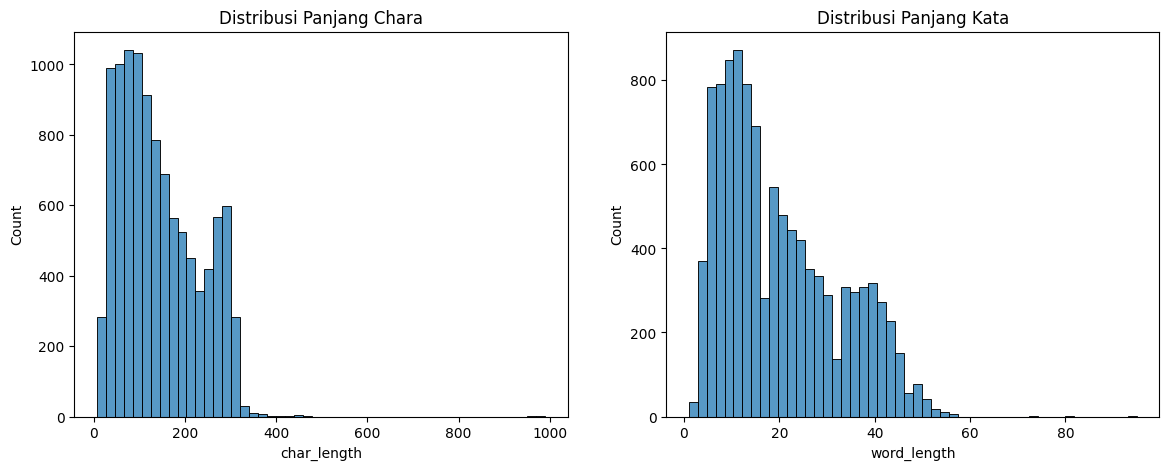

In [ ]:
# Visualize Char and Word
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df['char_length'], bins=50, ax=axes[0], palette='viridis')
axes[0].set_title("Distribusi Panjang Chara")


sns.histplot(df['word_length'], bins=50, ax=axes[1], palette='viridis')
axes[1].set_title("Distribusi Panjang Kata")

plt.show()

> Distribusinya condong ke kanan, berarti tweet pendek lebih dominan.

/tmp/ipykernel_1284/1111477805.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'])
/tmp/ipykernel_1284/1111477805.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(


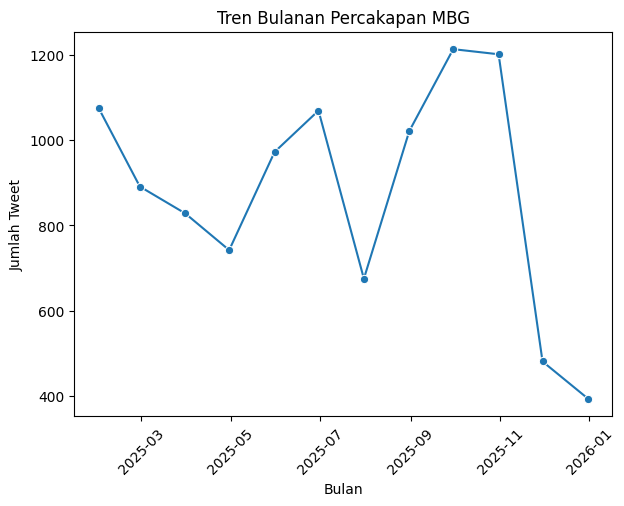

In [ ]:
def setup_plot(title, xlabel, ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()

# Konversi date
df['created_at'] = pd.to_datetime(df['created_at'])
tweet_monthly = (
    df
    .groupby(pd.Grouper(
        key='created_at',
        freq='M'
    ))
    .size()
    .reset_index(name='tweet_count')
)
sns.lineplot(
    data=tweet_monthly,
    x='created_at',
    y='tweet_count',
    marker='o',
)
setup_plot("Tren Bulanan Percakapan MBG", "Bulan", "Jumlah Tweet")
plt.xticks(rotation=45)
plt.show()

> Percakapan MBG terlihat naik turun sepanjang tahun. Diskusi paling ramai terjadi pada Oktober–November, menandakan adanya momentum yang membuat perhatian publik meningkat.

/tmp/ipykernel_1284/1186641970.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


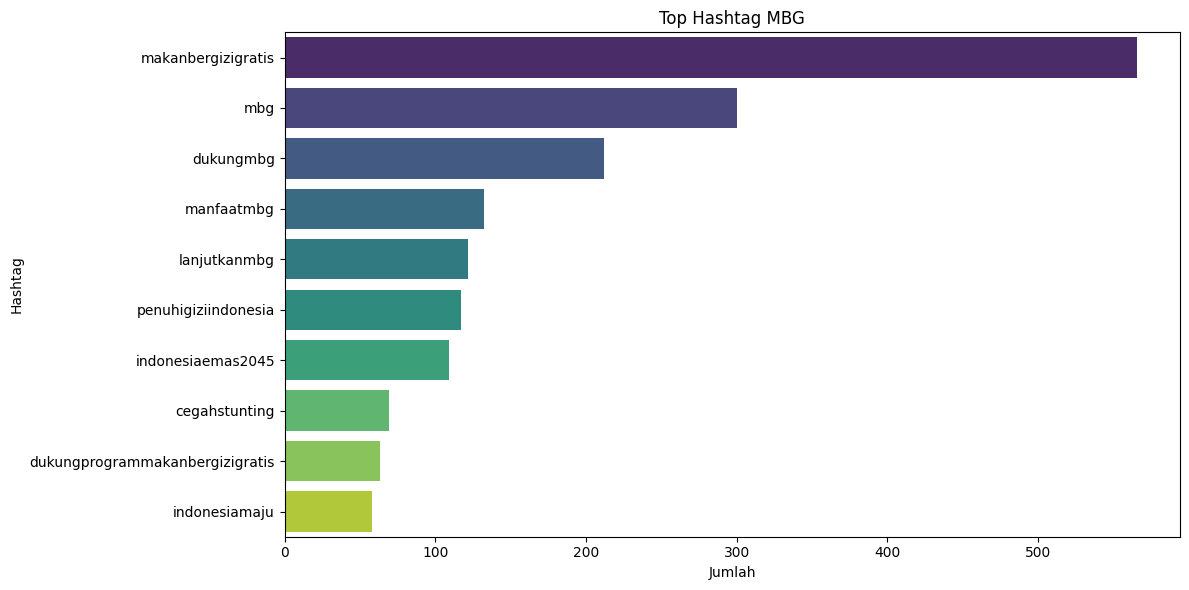

In [ ]:
# Extract hashtag
def extract_hashtags(x):
    try:
        hashtags = ast.literal_eval(x)

        return [
            tag.lower()
            for tag in hashtags
        ]
    except:
        return []

df['hashtags_clean'] = df['hashtags'].apply(extract_hashtags)

all_hashtags = []
for tags in df['hashtags_clean']:
    all_hashtags.extend(tags)
hashtag_freq = Counter(all_hashtags)
top_hashtags = pd.DataFrame(
    hashtag_freq.most_common(10),
    columns=['hashtag', 'count']
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_hashtags,
    x='count',
    y='hashtag',
    palette='viridis'
)
setup_plot("Top Hashtag MBG", "Jumlah", "Hashtag")
plt.show()

> Dominasi hashtag seperti #makanbergizigratis dan #dukungmbg menunjukkan bahwa diskusi MBG banyak dikaitkan dengan narasi dukungan program dan peningkatan gizi masyarakat.

/tmp/ipykernel_1284/483790725.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


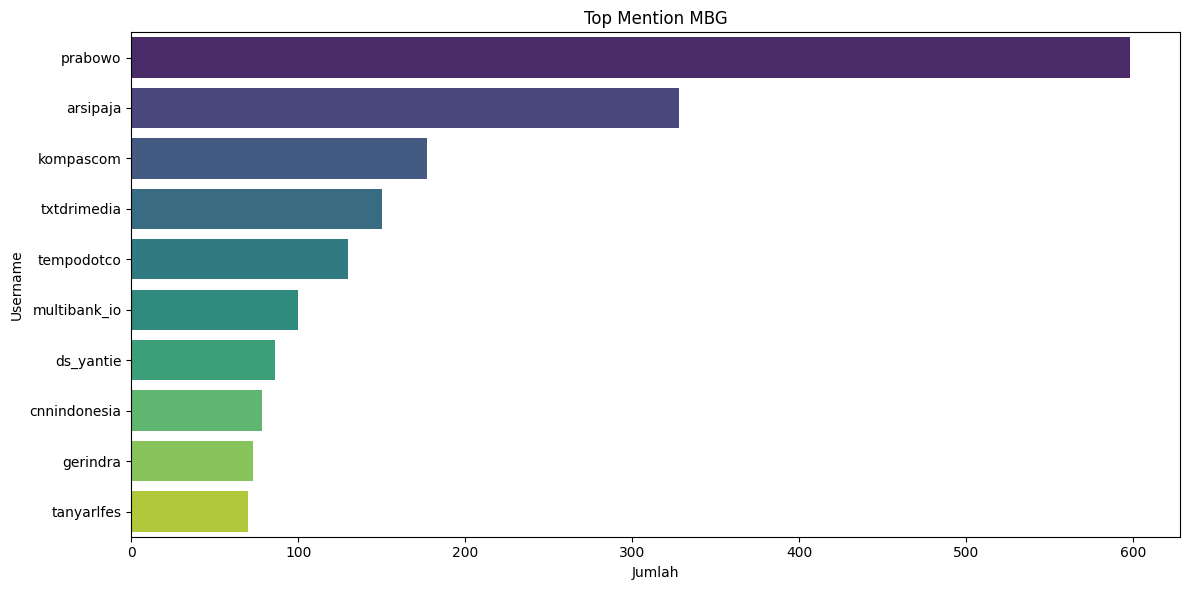

In [ ]:
# Extract Mention
def extract_mentions(x):
    try:
        mentions = ast.literal_eval(x)

        return [
            mention['username'].lower()
            for mention in mentions
            if 'username' in mention
        ]
    except:
        return []

df['mentions_clean'] = df['mentions'].apply(extract_mentions)
all_mentions = []

for mentions in df['mentions_clean']:
    all_mentions.extend(mentions)
mention_freq = Counter(all_mentions)
top_mentions = pd.DataFrame(
    mention_freq.most_common(10),
    columns=['username', 'count']
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_mentions,
    x='count',
    y='username',
    palette='viridis'
)
setup_plot("Top Mention MBG", "Jumlah", "Username")
plt.show()

> Mention paling banyak mengarah ke akun seperti @prabowo, @arsipaja, dan beberapa akun media, yang menunjukkan bahwa diskusi MBG banyak berpusat pada tokoh publik dan penyebaran informasi oleh media. (informasi organik dan anorganik belum dipisah)

In [ ]:
def clean_text(text):
    text = str(text).lower()

    # remove url
    text = re.sub(r"http\S+", "", text)

    # remove mention
    text = re.sub(r"@\w+", "", text)

    # remove hashtag symbol only
    text = re.sub(r"#", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

custom_stopwords = {
    'yg', 'aja', 'ga', 'gak', 'nya',
    'udah', 'jadi', 'buat', 'kalo',
    'bgt', 'nih', 'lah', 'utk',
    'emang', 'banget', 'sih',
    'kayak', 'mah', 'kan',
    'aku', 'gue', 'gw', 'lu',
    'program', 'makan', 'bergizi',
    'gratis', 'mbg', 'amp',
    'apa', 'semua', 'sama',
    'krn', 'jd', 'jg', 'tp',
    'pak', 'tuh', 'cuma',
    'lebih', 'terus', 'orang',
    'anak', 'banyak', 'gk',
    'kok', 'mana', 'bikin',
    'dapet', 'gitu', 'dong', 'mau', 'ku',
    'klo', 'bener', 'is', 'dr', 'tdk', 'rp',
    'jt'
}

# Sastrawi
stopword_factory = StopWordRemoverFactory()
stopwords_sastrawi = set(
    stopword_factory.get_stop_words()
)

# NLP-ID
stopword_nlp = StopWord()
stopwords_nlp_id = set(
    stopword_nlp.get_stopword()
)

# Gabungkan semua
all_stopwords = (
    stopwords_sastrawi
    .union(stopwords_nlp_id)
    .union(custom_stopwords)
)

def clean_stopwords(text):

    words = text.split()

    filtered_words = [
        word
        for word in words
        if word not in all_stopwords
    ]

    return " ".join(filtered_words)


def generate_ngram(texts, n=2, top_k=10):
    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        max_features=top_k,
        stop_words=None
    )

    X = vectorizer.fit_transform(texts)

    total_counts = X.sum(axis=0)

    ngram_freq = [
        (ngram, total_counts[0, idx])
        for ngram, idx in vectorizer.vocabulary_.items()
    ]

    ngram_freq = sorted(
        ngram_freq,
        key=lambda x: x[1],
        reverse=True
    )

    return pd.DataFrame(
        ngram_freq,
        columns=['ngram', 'frequency']
    )

def generate_ngram(
    texts,
    n,
    top_k=10,
    method='count'
):

    if method == 'count':

        vectorizer = CountVectorizer(
            ngram_range=(n,n),
            max_features=top_k,
            min_df=1
        )

    elif method == 'tfidf':

        vectorizer = TfidfVectorizer(
            ngram_range=(n,n),
            max_features=top_k,
            min_df=1
        )

    X = vectorizer.fit_transform(texts)

    scores = X.sum(axis=0).A1

    terms = vectorizer.get_feature_names_out()

    result_df = pd.DataFrame({
        'ngram': terms,
        'score': scores
    })

    result_df = (
        result_df
        .sort_values(
            by='score',
            ascending=False
        )
    )

    return result_df

def plot_three_ngram(
    texts,
    top_k=10,
    method='count'
):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(20,6)
    )

    for i, n in enumerate([1,2,3]):

        plot_data = generate_ngram(
            texts,
            n=n,
            top_k=top_k,
            method=method
        )

        sns.barplot(
            data=plot_data,
            x='score',
            y='ngram',
            hue='ngram',
            palette='viridis',
            legend=False,
            ax=axes[i]
        )

        title_method = (
            'TF-IDF'
            if method == 'tfidf'
            else 'Frequency'
        )

        axes[i].set_title(
            f'Top {title_method} {n}-Gram'
        )

        axes[i].set_xlabel(
            title_method
        )

        axes[i].set_ylabel(
            'N-Gram'
        )

    plt.suptitle(
        f'{title_method} N-Gram Analysis MBG',
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

In [ ]:
df['sentiment_text'] = df['full_text'].apply(clean_text)
df['topic_text'] = df['sentiment_text'].apply(clean_stopwords)
df[['full_text', 'sentiment_text', 'topic_text']].head(10)

,full_text,sentiment_text,topic_text
0,Surat Edaran (SE) Ditjen Pendis Kemenag Nomor ...,surat edaran se ditjen pendis kemenag nomor ta...,surat edaran ditjen pendis kemenag nomor menga...
1,PROGRAM MAKAN BERGIZI GRATIS UNTUK ANEUK ACEH\...,program makan bergizi gratis untuk aneuk aceh ...,aneuk aceh penuhigiziindonesia indonesiaemas a...
2,@abu_waras @prabowo Sdh pertengahan Januari 20...,sdh pertengahan januari sampai skrg blm ada li...,sdh pertengahan januari skrg blm list disekola...
3,@bahlilngntot @tanyakanrl Agen mbg,agen mbg,agen
4,Program MBG = bukan bisnis. Ini gerakan sosial...,program mbg bukan bisnis ini gerakan sosial ya...,bisnis gerakan sosial peduli kesehatan anakana...
5,Makanan bergizi adalah hak semua orang. Ayo du...,makanan bergizi adalah hak semua orang ayo duk...,makanan hak ayo dukung asupan butuhkan dukungm...
6,Seribu manfaat dari Program Makan Bergizi Grat...,seribu manfaat dari program makan bergizi grat...,seribu manfaat manfaatmakanbergizigratis makan...
7,MBG Makanan Beracun Gratis,mbg makanan beracun gratis,makanan beracun
8,@WagimanDeep212_ @prabowo Stop MBG Pak Preside...,stop mbg pak presiden dananya dialihkan untuk ...,stop presiden dananya dialihkan gaji guru perb...
9,@ssrieyono @yusuf_dumdum @prabowo Puasa MBG li...,puasa mbg libur efisiensi,puasa libur efisiensi


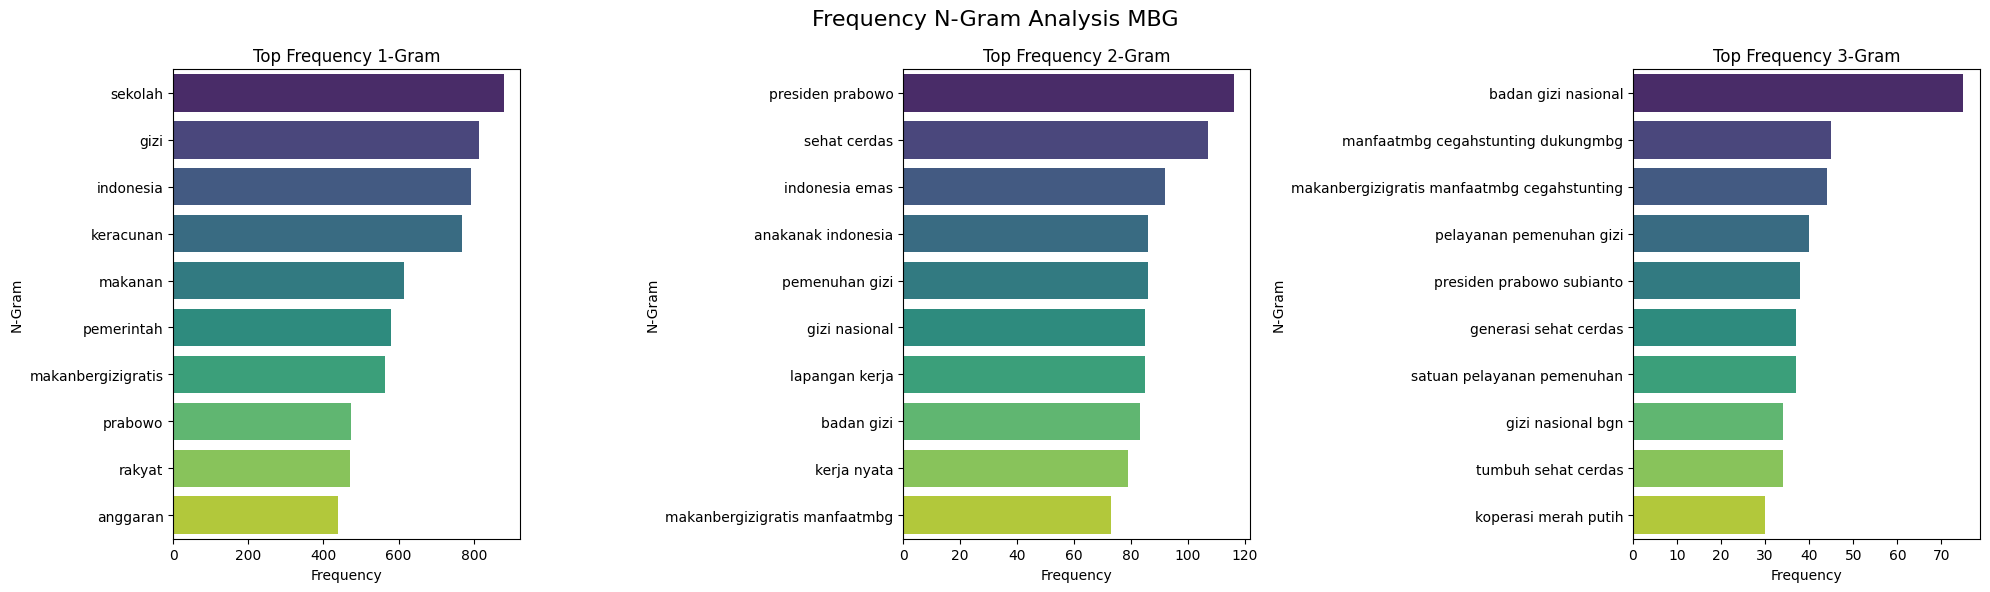

In [ ]:
plot_three_ngram(df['topic_text'], method='count')

> Bigram dan trigram lebih representatif karena menampilkan konteks pembahasan seperti “makan bergizi gratis” dan “program makan bergizi,”

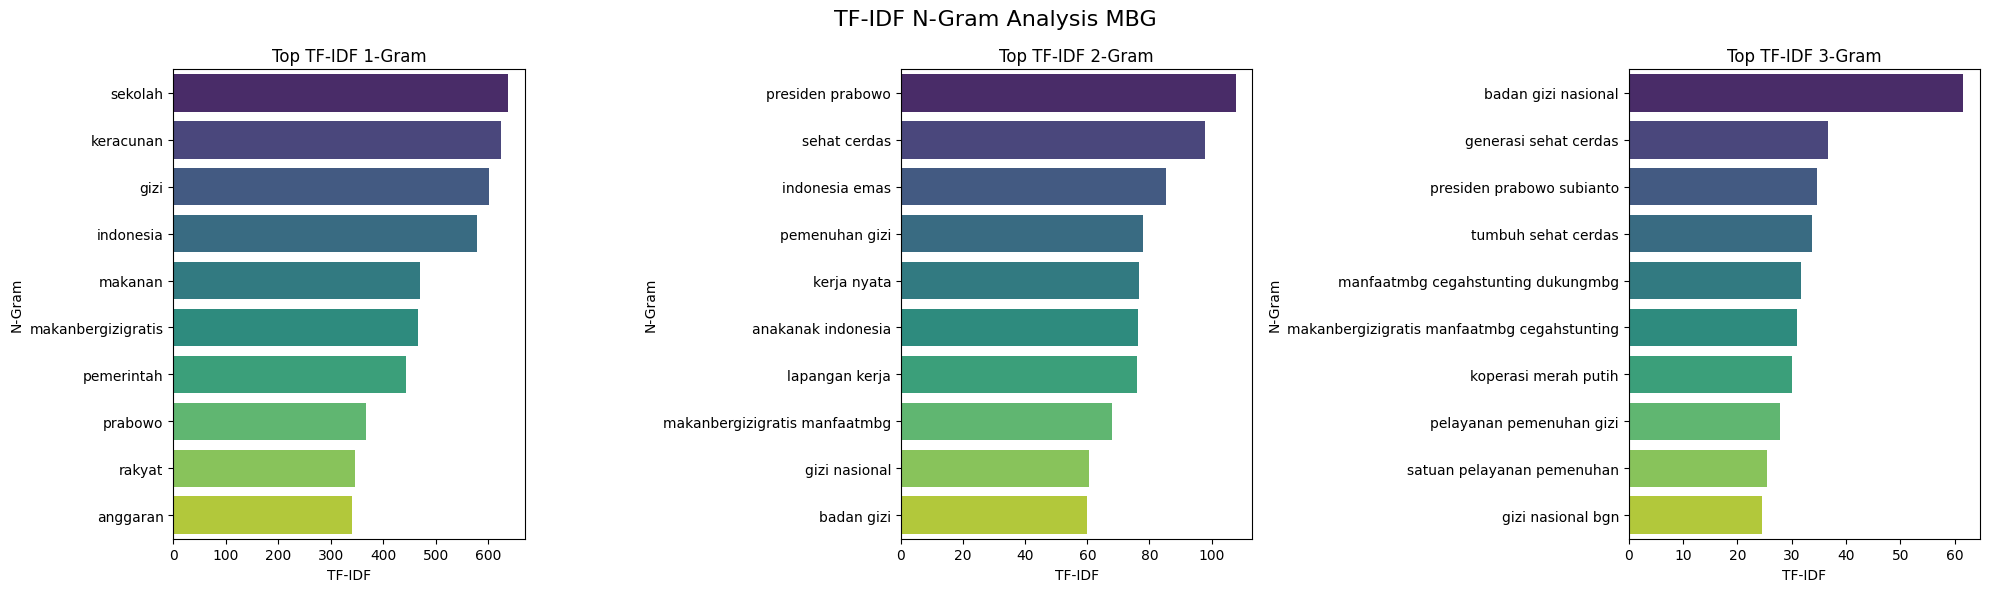

In [ ]:
def generate_tfidf_ngram(
    texts,
    n,
    top_k=10
):

    vectorizer = TfidfVectorizer(
        ngram_range=(n,n),
        max_features=top_k
    )

    X = vectorizer.fit_transform(texts)

    scores = X.sum(axis=0).A1

    terms = vectorizer.get_feature_names_out()

    tfidf_df = pd.DataFrame({
        'ngram': terms,
        'score': scores
    })

    tfidf_df = (
        tfidf_df
        .sort_values(
            by='score',
            ascending=False
        )
    )

    return tfidf_df

def plot_three_tfidf_ngram(
    texts,
    top_k=10
):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(20,6)
    )

    for i, n in enumerate([1,2,3]):

        plot_data = generate_tfidf_ngram(
            texts,
            n=n,
            top_k=top_k
        )

        sns.barplot(
            data=plot_data,
            x='score',
            y='ngram',
            hue='ngram',
            palette='viridis',
            legend=False,
            ax=axes[i]
        )

        axes[i].set_title(
            f'Top TF-IDF {n}-Gram'
        )

        axes[i].set_xlabel(
            'TF-IDF Score'
        )

        axes[i].set_ylabel(
            'N-Gram'
        )

    plt.suptitle(
        'TF-IDF N-Gram Analysis MBG',
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

plot_three_ngram(df['topic_text'], method="tfidf")

> Setelah diterapkan TF-IDF, hasil analisis menunjukkan bahwa unigram masih didominasi kata umum seperti sekolah, keracunan, makanan, pemerintah, sedangkan bigram dan trigram lebih representatif karena menampilkan konteks kebijakan dan program, misalnya presiden prabowo, pemenuhan gizi, badan gizi nasional, generasi sehat cerdas, sehingga terlihat jelas isu gizi, pendidikan, politik, dan bahkan kasus keracunan ikut terangkat sebagai topik penting.

In [ ]:
# Distribusi User
total_users = df['user_id'].nunique()
print("Total Unique Users:", total_users)

Total Unique Users: 7477


In [ ]:
verified_users = (
    df[df['verified'] == True]['user_id']
    .nunique()
)

non_verified_users = (
    df[df['verified'] == False]['user_id']
    .nunique()
)

actor_df = pd.DataFrame({
    'category': ['Verified', 'Non-Verified'],
    'count': [verified_users, non_verified_users]
})

actor_df

,category,count
0,Verified,283
1,Non-Verified,7205


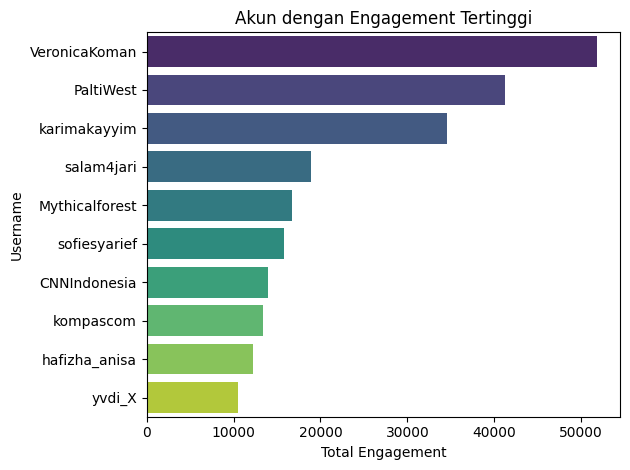

In [ ]:
df['engagement'] = (
    df['favorite_count'] +
    df['retweet_count'] +
    df['reply_count'] +
    df['quote_count']
)

engagement_df = (
    df.groupby('verified')['engagement']
    .mean()
    .reset_index()
)

engagement_df['verified'] = (
    engagement_df['verified']
    .map({
        True: 'Verified',
        False: 'Non-Verified'
    })
)

top_accounts = (
    df.groupby('username')['engagement']
    .sum()
    .reset_index()
    .sort_values(by='engagement', ascending=False)
    .head(10)
)

# Top engagement accounts
sns.barplot(
    data=top_accounts,
    x='engagement',
    y='username',
    hue='username',
    palette='viridis',
    legend=False,
)
setup_plot("Akun dengan Engagement Tertinggi", "Total Engagement", "Username")

plt.tight_layout()
plt.show()

> Grafik engagement memperlihatkan bahwa interaksi tersebar pada akun individu maupun media, dengan VeronicaKoman mencatat angka tertinggi lebih dari 50 ribu, diikuti akun individu lain seperti PaltiWest dan karimakayyiim, sementara akun media seperti CNNIndonesia dan kompascom berada di kisaran 15 ribu, menunjukkan distribusi narasi yang lebih kuat pada figur personal dibanding institusi.

In [ ]:
# Topic modelling
def show_topics(
    model,
    feature_names,
    top_words=10
):

    for topic_idx, topic in enumerate(model.components_):

        print(f"\nTopic {topic_idx + 1}")

        words = [
            feature_names[i]
            for i in topic.argsort()[:-top_words - 1:-1]
        ]

        print(", ".join(words))

lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

count_vectorizer = CountVectorizer(
    max_df=0.9,
    min_df=5
)

document_term_matrix = (
    count_vectorizer.fit_transform(
        df['topic_text']
    )
)

lda_model.fit(document_term_matrix)
feature_names = (count_vectorizer.get_feature_names_out())
show_topics(lda_model, feature_names)


Topic 1
sekolah, rakyat, menu, uang, pemerintah, duit, anggaran, makanan, murid, guru

Topic 2
keracunan, makanan, biar, tau, gini, sekolah, susu, udh, liat, dikasih

Topic 3
keracunan, bgn, makanan, lanjutkan, siswa, gizi, dana, anggaran, korban, kepala

Topic 4
prabowo, negara, presiden, anggaran, pendidikan, dapur, rakyat, keracunan, indonesia, efisiensi

Topic 5
gizi, indonesia, makanbergizigratis, sehat, anakanak, dukung, generasi, pemerintah, nyata, bangsa


In [ ]:
topic_distribution = lda_model.transform(
    document_term_matrix
)
df['dominant_topic'] = (
    topic_distribution.argmax(axis=1)
)

df[['topic_text', 'dominant_topic']].head()

,topic_text,dominant_topic
0,surat edaran ditjen pendis kemenag nomor menga...,2
1,aneuk aceh penuhigiziindonesia indonesiaemas a...,4
2,sdh pertengahan januari skrg blm list disekola...,1
3,agen,0
4,bisnis gerakan sosial peduli kesehatan anakana...,4


In [ ]:
df['dominant_topic'].value_counts()

,count
dominant_topic,
0,2540
4,2357
1,2078
3,1897
2,1689


/tmp/ipykernel_1284/1214765100.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


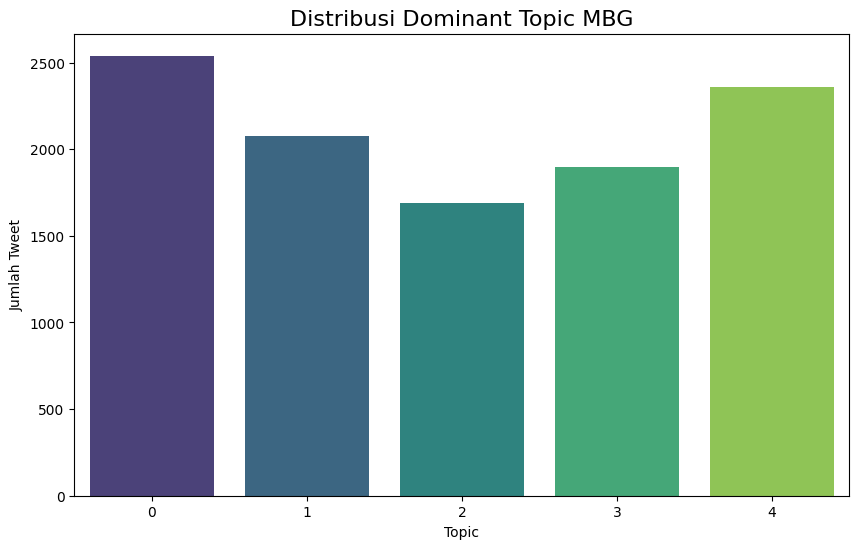

In [ ]:
topic_counts = (
    df['dominant_topic']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=topic_counts.index,
    y=topic_counts.values,
    palette='viridis'
)

plt.title(
    'Distribusi Dominant Topic MBG',
    fontsize=16
)

plt.xlabel('Topic')

plt.ylabel('Jumlah Tweet')

plt.show()

> Hasil topic modeling menunjukkan bahwa diskursus MBG didominasi oleh isu dukungan program dan gizi nasional, diikuti pembahasan mengenai anggaran negara, implementasi di sekolah, serta kasus keracunan makanan yang menjadi perhatian publik.

In [ ]:
# CNA
id_to_username = dict(zip(df['user_id'].astype(str), df['username']))

interaction_graph = nx.DiGraph()

for _, row in df.iterrows():

    source = str(row['username'])

    # Mention
    mentions = row['mentions']

    try:
        mentions = ast.literal_eval(mentions)

        if isinstance(mentions, list):

            for mention in mentions:
                target_id = mention.get('user_id')
                target_username = mention.get('username')
                if target_id:
                    target = id_to_username.get(
                        str(target_id),
                        target_username
                    )
                    if target:
                        if interaction_graph.has_edge(source, target):
                            interaction_graph[source][target]['weight'] += 1
                        else:
                            interaction_graph.add_edge(
                                source,
                                target,
                                weight=1,
                                interaction='mention'
                            )

    except:
        pass


    # Reply
    reply_target = row['in_reply_to_user_id']

    if pd.notna(reply_target):
        target = id_to_username.get(
            str(reply_target),
            row['in_reply_to_screen_name']
        )
        if pd.notna(target):
            if interaction_graph.has_edge(source, target):
                interaction_graph[source][target]['weight'] += 1
            else:
                interaction_graph.add_edge(
                    source,
                    target,
                    weight=1,
                    interaction='reply'
                )

    # Quote
    quote_target = row['quoted_username']

    if pd.notna(quote_target):
        quote_target = str(quote_target)
        if interaction_graph.has_edge(source, quote_target):
            interaction_graph[source][quote_target]['weight'] += 1
        else:
            interaction_graph.add_edge(
                source,
                quote_target,
                weight=1,
                interaction='quote'
            )


# Filter low degree node
low_degree_nodes = [
    node for node, degree in interaction_graph.degree()
    if degree < 2
]

interaction_graph.remove_nodes_from(low_degree_nodes)

print("Jumlah Nodes:", interaction_graph.number_of_nodes())
print("Jumlah Edges:", interaction_graph.number_of_edges())

Jumlah Nodes: 3087
Jumlah Edges: 5237


In [ ]:
def plot_all_centrality(graph):

    degree = nx.degree_centrality(graph)

    betweenness = nx.betweenness_centrality(
        graph,
        k=100,
        seed=42
    )

    eigen = nx.eigenvector_centrality(
        graph,
        max_iter=1000
    )


    degree_df = (
        pd.DataFrame({
            'username':degree.keys(),
            'value':degree.values()
        })
        .sort_values(
            'value',
            ascending=False
        )
        .head(10)
    )

    between_df = (
        pd.DataFrame({
            'username':betweenness.keys(),
            'value':betweenness.values()
        })
        .sort_values(
            'value',
            ascending=False
        )
        .head(10)
    )

    eigen_df = (
        pd.DataFrame({
            'username':eigen.keys(),
            'value':eigen.values()
        })
        .sort_values(
            'value',
            ascending=False
        )
        .head(10)
    )


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(24,8)
    )


    sns.barplot(
        data=degree_df,
        x='value',
        y='username',
        hue='username',
        legend=False,
        ax=axes[0]
    )

    axes[0].set_title(
        'Degree Centrality'
    )


    sns.barplot(
        data=between_df,
        x='value',
        y='username',
        hue='username',
        legend=False,
        ax=axes[1]
    )

    axes[1].set_title(
        'Betweenness Centrality'
    )


    sns.barplot(
        data=eigen_df,
        x='value',
        y='username',
        hue='username',
        legend=False,
        ax=axes[2]
    )

    axes[2].set_title(
        'Eigenvector Centrality'
    )


    plt.tight_layout()
    plt.show()

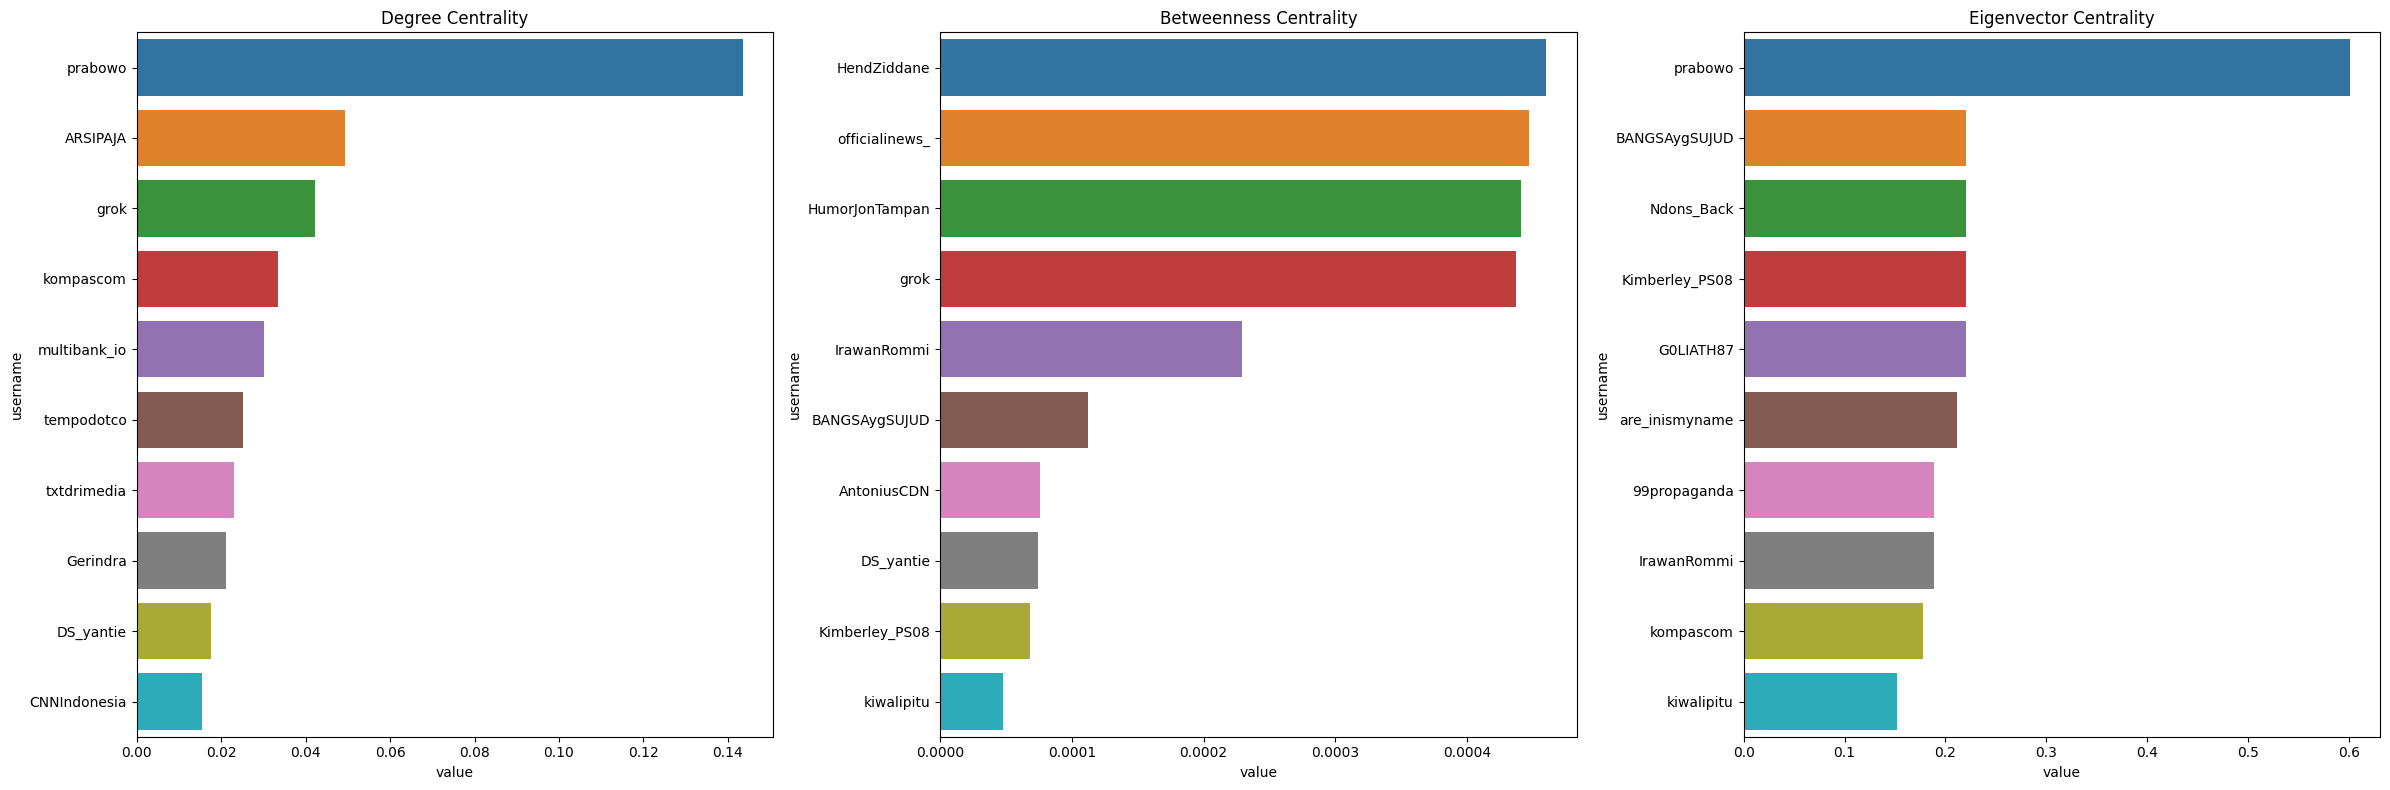

In [ ]:
plot_all_centrality(interaction_graph)

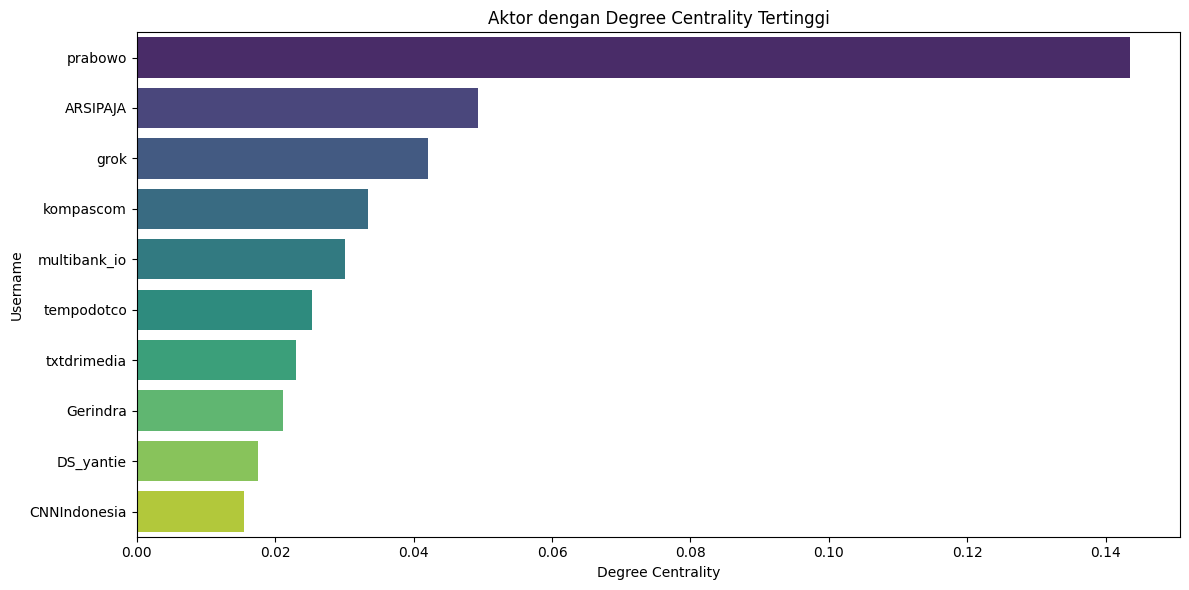

In [ ]:
# Kalkulasi Degree Centrality
degree_centrality = nx.degree_centrality(interaction_graph)

centrality_df = pd.DataFrame({
    'username': degree_centrality.keys(),
    'degree_centrality': degree_centrality.values()
})

top_degree = centrality_df.sort_values(
    by='degree_centrality',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_degree,
    x='degree_centrality',
    y='username',
    hue='username',
    palette='viridis',
    legend=False
)

setup_plot(
    "Aktor dengan Degree Centrality Tertinggi",
    "Degree Centrality",
    "Username"
)

plt.show()

> Grafik degree centrality menunjukkan Prabowo paling tinggi (≈0,14), diikuti akun lain seperti ARSIPAJA, grok, kompascom.

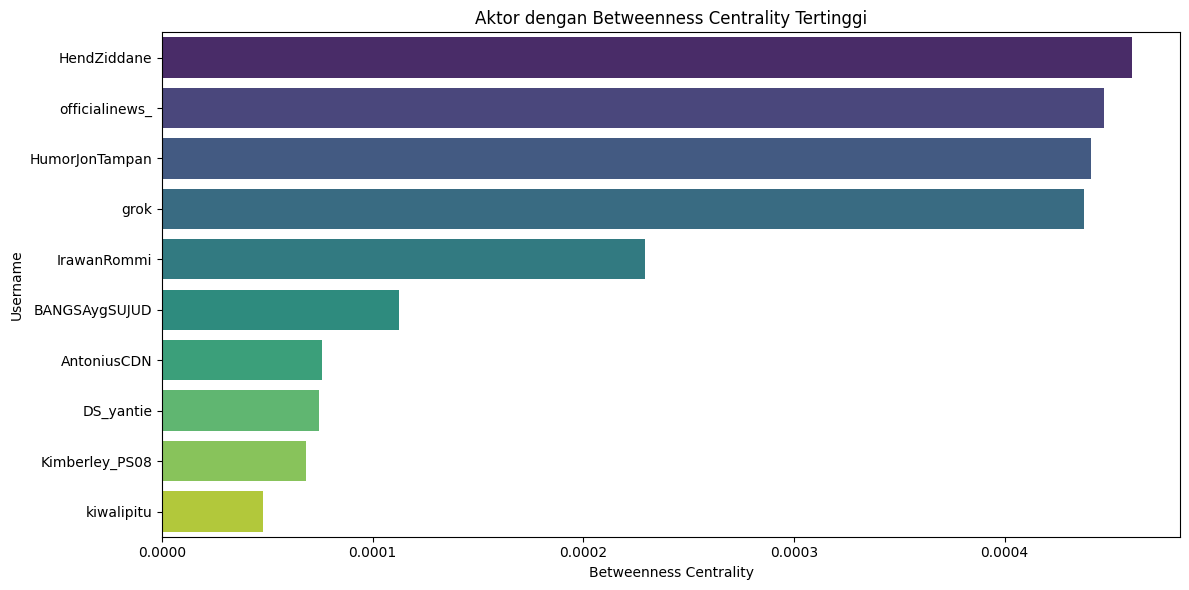

In [ ]:
# Kalkulasi Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(interaction_graph, k=100, seed=42)

betweenness_df = pd.DataFrame({
    'username': betweenness_centrality.keys(),
    'betweenness_centrality': betweenness_centrality.values()
})

top_betweenness = betweenness_df.sort_values(
    by='betweenness_centrality',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_betweenness,
    x='betweenness_centrality',
    y='username',
    hue='username',
    palette='viridis',
    legend=False
)

setup_plot(
    "Aktor dengan Betweenness Centrality Tertinggi",
    "Betweenness Centrality",
    "Username"
)

plt.show()

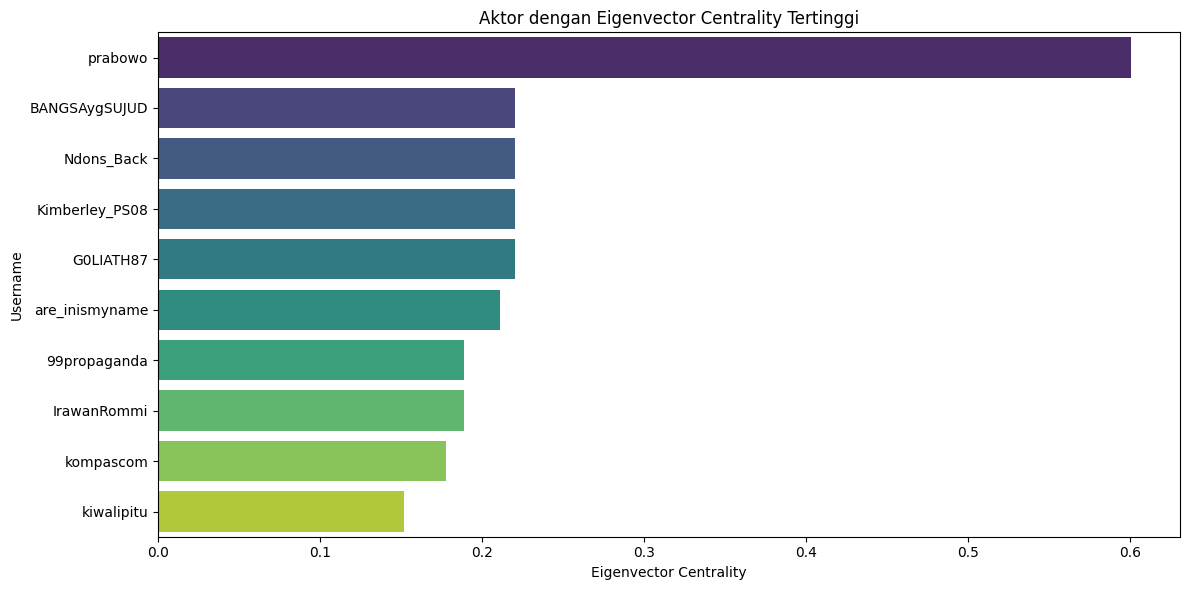

In [ ]:
# Kalkulasi eigentvector centrality
eigenvector_centrality = (nx.eigenvector_centrality(interaction_graph, max_iter=1000))

eigenvector_df = pd.DataFrame({
    'username': eigenvector_centrality.keys(),
    'eigenvector_centrality': eigenvector_centrality.values()
})

top_eigenvector = (
    eigenvector_df
    .sort_values(
        by='eigenvector_centrality',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_eigenvector,
    x='eigenvector_centrality',
    y='username',
    hue='username',
    palette='viridis',
    legend=False
)
setup_plot("Aktor dengan Eigenvector Centrality Tertinggi", "Eigenvector Centrality", "Username")
plt.show()


In [ ]:
# Network Density pada (mention)
density = nx.density(interaction_graph)

print("Network Density:", density)

Network Density: 0.0005497307400570326


In [ ]:
# Kecendrungan membentuk kelompok (mention)
undirected_graph = (interaction_graph.to_undirected())
clustering = nx.average_clustering(undirected_graph)

print("Average Clustering Coefficient:",clustering)

Average Clustering Coefficient: 0.05393168794526716


In [ ]:
# Mean jarak antar user (mention)
largest_component = max(nx.connected_components(undirected_graph),key=len)
largest_subgraph = (undirected_graph.subgraph(largest_component))
avg_path_length = (nx.average_shortest_path_length(largest_subgraph))

print("Average Path Length:",avg_path_length)

Average Path Length: 4.57201845079429


In [ ]:
# Comunity Detection
# !pip install python-louvain
import community.community_louvain as community_louvain
undirected_graph = (
    interaction_graph.to_undirected()
)
partition = (
    community_louvain.best_partition(
        undirected_graph
    )
)
community_df = pd.DataFrame(
    partition.items(),
    columns=[
        'username',
        'community'
    ]
)
community_df.head(10)

,username,community
0,ZainAris,0
1,abu_waras,0
2,prabowo,0
3,hereseans,22
4,tanyakanrl,22
5,Dayak2018,2
6,WagimanDeep212_,2
7,hsbhekti,3
8,yusuf_dumdum,3
9,IniNana_05,4


In [ ]:
community_size = (
    community_df['community']
    .value_counts()
    .reset_index()
)

community_size.columns = [
    'community',
    'count'
]

community_size.head(10)

,community,count
0,0,250
1,24,213
2,9,183
3,3,169
4,14,135
5,12,120
6,25,113
7,19,99
8,11,96
9,10,92


/tmp/ipykernel_1284/4001549105.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


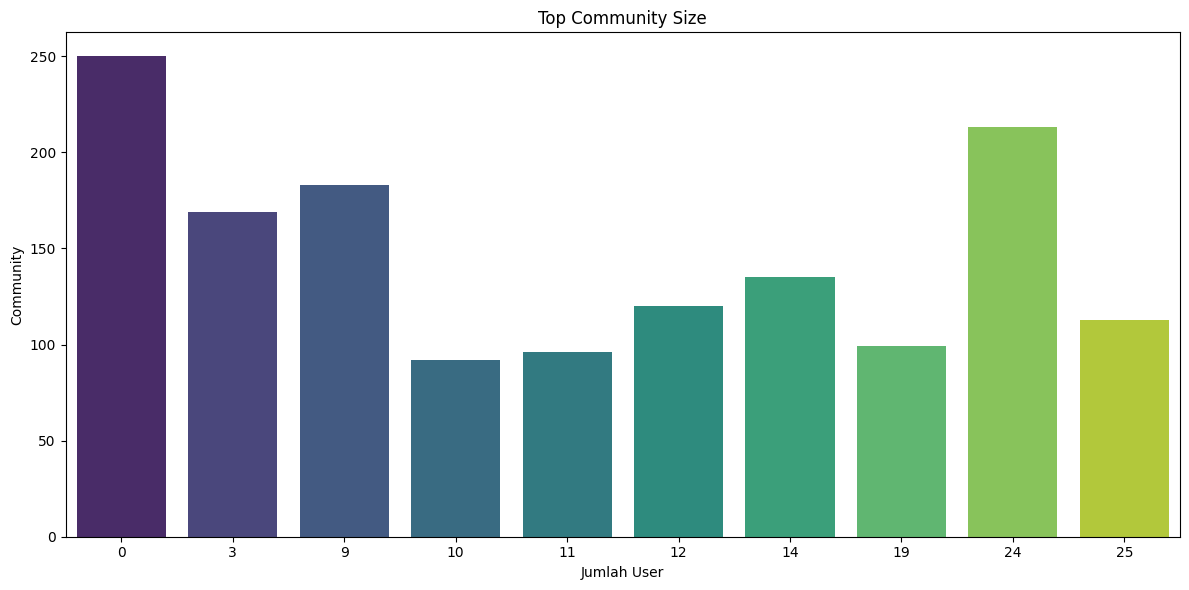

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=community_size.head(10),
    x='community',
    y='count',
    palette='viridis'
)
setup_plot("Top Community Size", "Jumlah User", "Community")
plt.show()

> Hasil community detection menunjukkan bahwa diskursus MBG terbagi ke dalam beberapa komunitas interaksi, dengan Community 1 menjadi kelompok paling dominan dalam jaringan. (ini gak menjelaskan saya masih bingung saat ingin dikaitkan ke dominant topic nya terlalu kepisah pisah communitynya)

In [ ]:
# Modularity Score
modularity_score = (community_louvain.modularity(partition, undirected_graph))

print("Modularity Score:", modularity_score)

Modularity Score: 0.7187034089584714


> Nilai modularity menunjukkan bahwa diskursus MBG membentuk komunitas yang cukup terpisah dalam jaringan interaksi.

> note: untuk saat ini organik dan anorganik belum dipisah, dan juga media dan non media masih disatukan, karena beberapa ada source di luar twitter jadi masih kecampur antara organik dan anorganik data

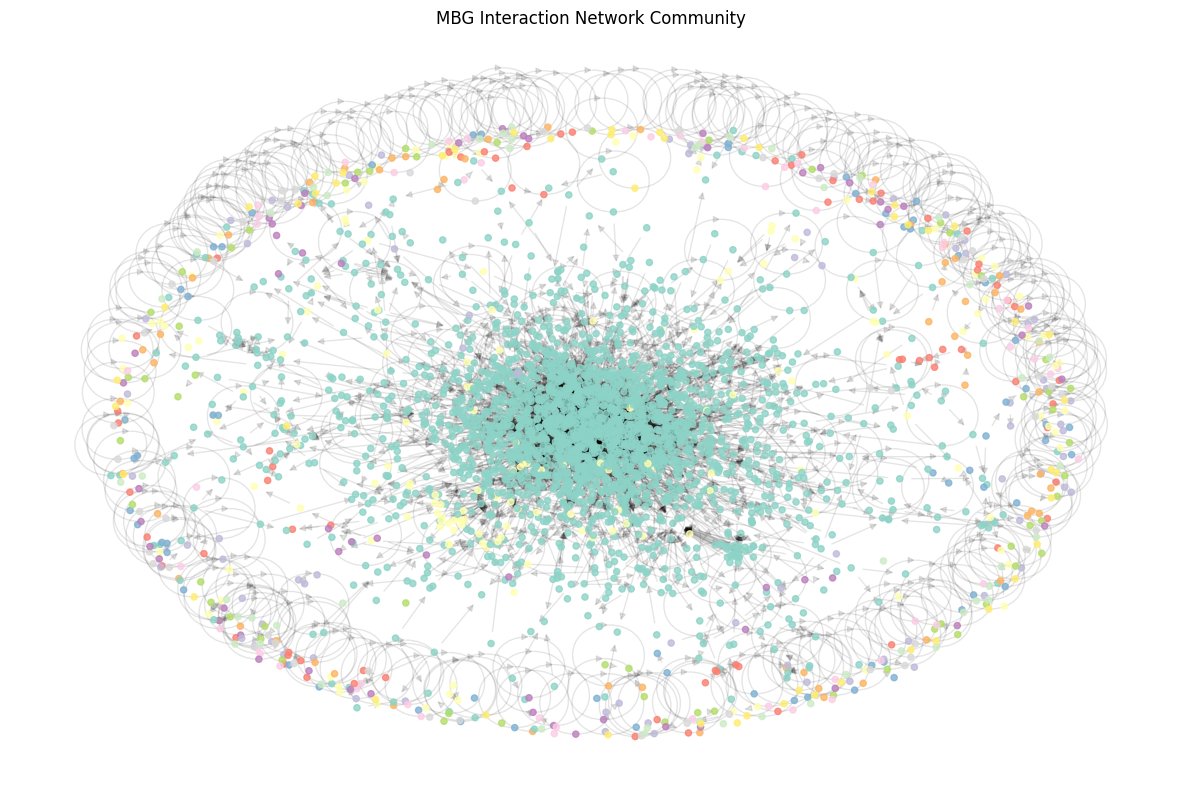

In [ ]:
# =========================================================
# VISUALISASI NETWORK
# =========================================================

plt.figure(figsize=(15,10))

pos = nx.spring_layout(
    interaction_graph,
    seed=42
)

communities = list(
    partition.values()
)

nx.draw_networkx_nodes(
    interaction_graph,
    pos,
    node_size=20,
    node_color=communities,
    cmap=plt.cm.Set3,
    alpha=0.8
)

nx.draw_networkx_edges(
    interaction_graph,
    pos,
    alpha=0.1
)

plt.title(
    "MBG Interaction Network Community"
)

plt.axis('off')

plt.show()

### ANALYSIS

In [ ]:
cols = [
    'full_text',
    'created_at',
    'username',
    'mentions',
    'hashtags',
    'favorite_count',
    'retweet_count',
    'sentiment_text',
    'topic_text'
]

analysis_df = df[cols].copy()
analysis_df.head(5)

,full_text,created_at,username,mentions,hashtags,favorite_count,retweet_count,sentiment_text,topic_text
0,Surat Edaran (SE) Ditjen Pendis Kemenag Nomor ...,2025-01-05 13:56:06+00:00,arinadotid,[],[],0,0,surat edaran se ditjen pendis kemenag nomor ta...,surat edaran ditjen pendis kemenag nomor menga...
1,PROGRAM MAKAN BERGIZI GRATIS UNTUK ANEUK ACEH\...,2025-04-05 13:36:34+00:00,ArifaNidya,[],"[""PenuhiGiziIndonesia"",""Indonesiaemas"",""AstaCi...",0,0,program makan bergizi gratis untuk aneuk aceh ...,aneuk aceh penuhigiziindonesia indonesiaemas a...
2,@abu_waras @prabowo Sdh pertengahan Januari 20...,2025-01-14 22:21:59+00:00,ZainAris,"[{""name"":""Lambe Waras"",""user_id"":""2905814730"",...",[],1,0,sdh pertengahan januari sampai skrg blm ada li...,sdh pertengahan januari skrg blm list disekola...
3,@bahlilngntot @tanyakanrl Agen mbg,2025-02-27 15:26:33+00:00,hereseans,"[{""name"":""Tanyarl 💚"",""user_id"":""13316505595189...",[],0,0,agen mbg,agen
4,Program MBG = bukan bisnis. Ini gerakan sosial...,2025-10-16 23:11:25+00:00,revirevii1,[],[],0,0,program mbg bukan bisnis ini gerakan sosial ya...,bisnis gerakan sosial peduli kesehatan anakana...


In [ ]:
analysis_df[
    [
        'full_text',
        'sentiment_text',
        'topic_text'
    ]
].head(10)

,full_text,sentiment_text,topic_text
0,Surat Edaran (SE) Ditjen Pendis Kemenag Nomor ...,surat edaran se ditjen pendis kemenag nomor ta...,surat edaran ditjen pendis kemenag nomor menga...
1,PROGRAM MAKAN BERGIZI GRATIS UNTUK ANEUK ACEH\...,program makan bergizi gratis untuk aneuk aceh ...,aneuk aceh penuhigiziindonesia indonesiaemas a...
2,@abu_waras @prabowo Sdh pertengahan Januari 20...,sdh pertengahan januari sampai skrg blm ada li...,sdh pertengahan januari skrg blm list disekola...
3,@bahlilngntot @tanyakanrl Agen mbg,agen mbg,agen
4,Program MBG = bukan bisnis. Ini gerakan sosial...,program mbg bukan bisnis ini gerakan sosial ya...,bisnis gerakan sosial peduli kesehatan anakana...
5,Makanan bergizi adalah hak semua orang. Ayo du...,makanan bergizi adalah hak semua orang ayo duk...,makanan hak ayo dukung asupan butuhkan dukungm...
6,Seribu manfaat dari Program Makan Bergizi Grat...,seribu manfaat dari program makan bergizi grat...,seribu manfaat manfaatmakanbergizigratis makan...
7,MBG Makanan Beracun Gratis,mbg makanan beracun gratis,makanan beracun
8,@WagimanDeep212_ @prabowo Stop MBG Pak Preside...,stop mbg pak presiden dananya dialihkan untuk ...,stop presiden dananya dialihkan gaji guru perb...
9,@ssrieyono @yusuf_dumdum @prabowo Puasa MBG li...,puasa mbg libur efisiensi,puasa libur efisiensi


In [ ]:
all_words = ' '.join(
    analysis_df['topic_text']
).split()

common_words = Counter(all_words).most_common(20)

print(common_words)

[('sekolah', 880), ('gizi', 815), ('indonesia', 792), ('keracunan', 769), ('makanan', 614), ('pemerintah', 581), ('makanbergizigratis', 565), ('prabowo', 473), ('rakyat', 470), ('anggaran', 439), ('dapur', 430), ('negara', 423), ('sehat', 416), ('anakanak', 400), ('presiden', 400), ('siswa', 389), ('kerja', 357), ('dukung', 342), ('pendidikan', 333), ('menu', 332)]


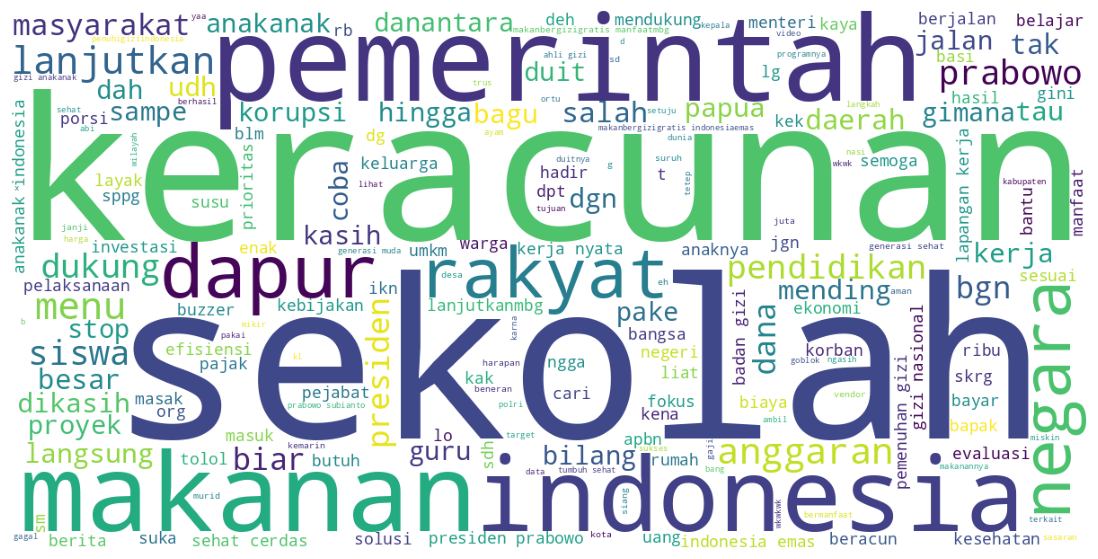

In [ ]:
from wordcloud import WordCloud

text = ' '.join(analysis_df['topic_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

### Sentiment Analysis

In [ ]:
def tokenize_text(text):

    text = str(text).lower()

    tokens = text.split()

    tokens = [
        word for word in tokens
    ]

    tokens = [
        word for word in tokens
        if len(word) > 2
    ]

    return tokens

In [ ]:
tqdm.pandas()

classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier"
)

texts = analysis_df['sentiment_text'].tolist()

results = classifier(
    texts,
    batch_size=32,
    truncation=True
)

analysis_df['sentiment'] = [
    r['label']
    for r in results
]

analysis_df['sentiment_score'] = [
    r['score']
    for r in results
]

analysis_df['sentiment_score']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

,sentiment_score
0,0.998888
1,0.968387
2,0.777350
3,0.942075
4,0.981238
...,...
10556,0.998170
10557,0.699095
10558,0.995366
10559,0.970451


In [ ]:
analysis_df.to_csv(
    "hasil_sentiment.csv",
    index=False
)

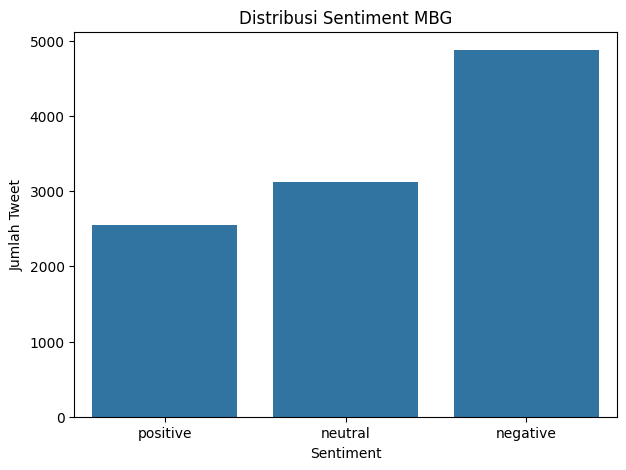

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=analysis_df,
    x='sentiment',
    order=['positive', 'neutral', 'negative']
)

plt.title("Distribusi Sentiment MBG")

plt.xlabel("Sentiment")
plt.ylabel("Jumlah Tweet")

plt.show()

In [ ]:
analysis_df['created_at'] = pd.to_datetime(
    analysis_df['created_at']
)

daily_sentiment = analysis_df.groupby(
    [
        analysis_df['created_at'].dt.date,
        'sentiment'
    ]
).size().unstack(fill_value=0)

daily_sentiment.head()

sentiment,negative,neutral,positive
created_at,,,
2025-01-01,3,1,1
2025-01-02,2,4,3
2025-01-03,1,5,1
2025-01-04,0,11,4
2025-01-05,0,20,3


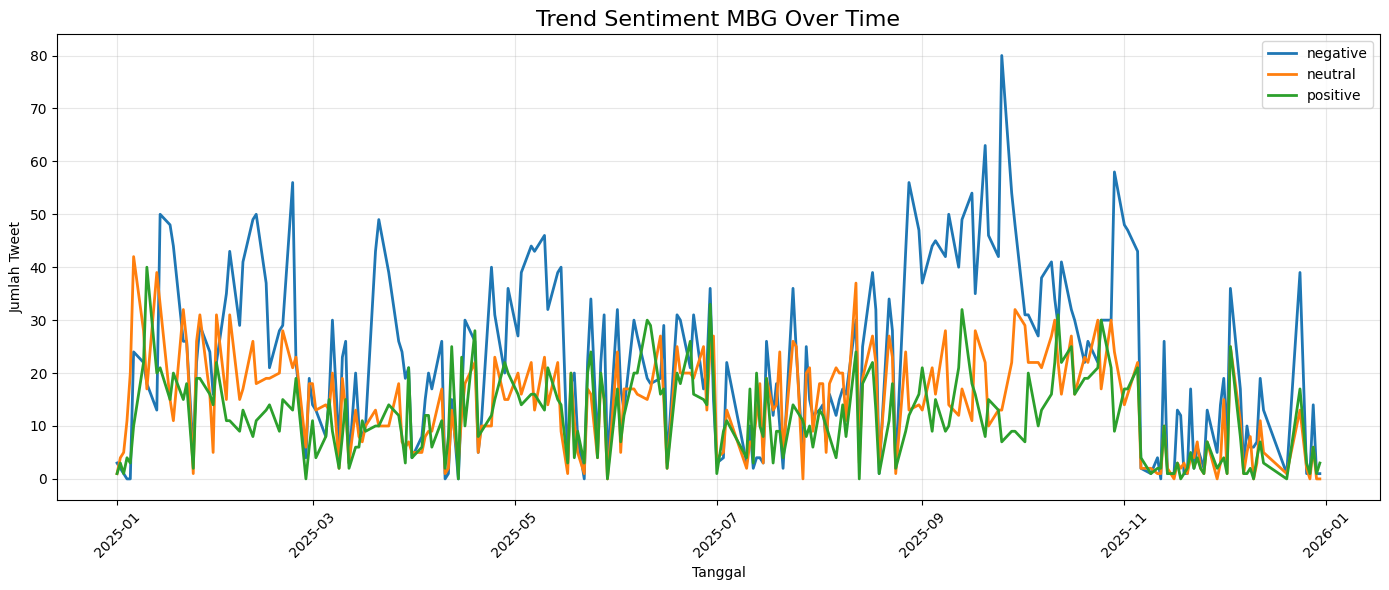

In [ ]:
plt.figure(figsize=(14,6))

for sentiment in daily_sentiment.columns:

    plt.plot(
        daily_sentiment.index,
        daily_sentiment[sentiment],
        label=sentiment,
        linewidth=2
    )

plt.title(
    "Trend Sentiment MBG Over Time",
    fontsize=16
)

plt.xlabel("Tanggal")
plt.ylabel("Jumlah Tweet")

plt.legend()

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
daily_percentage = daily_sentiment.div(
    daily_sentiment.sum(axis=1),
    axis=0
) * 100

daily_percentage.head()

sentiment,negative,neutral,positive
created_at,,,
2025-01-01,60.000000,20.000000,20.000000
2025-01-02,22.222222,44.444444,33.333333
2025-01-03,14.285714,71.428571,14.285714
2025-01-04,0.000000,73.333333,26.666667
2025-01-05,0.000000,86.956522,13.043478


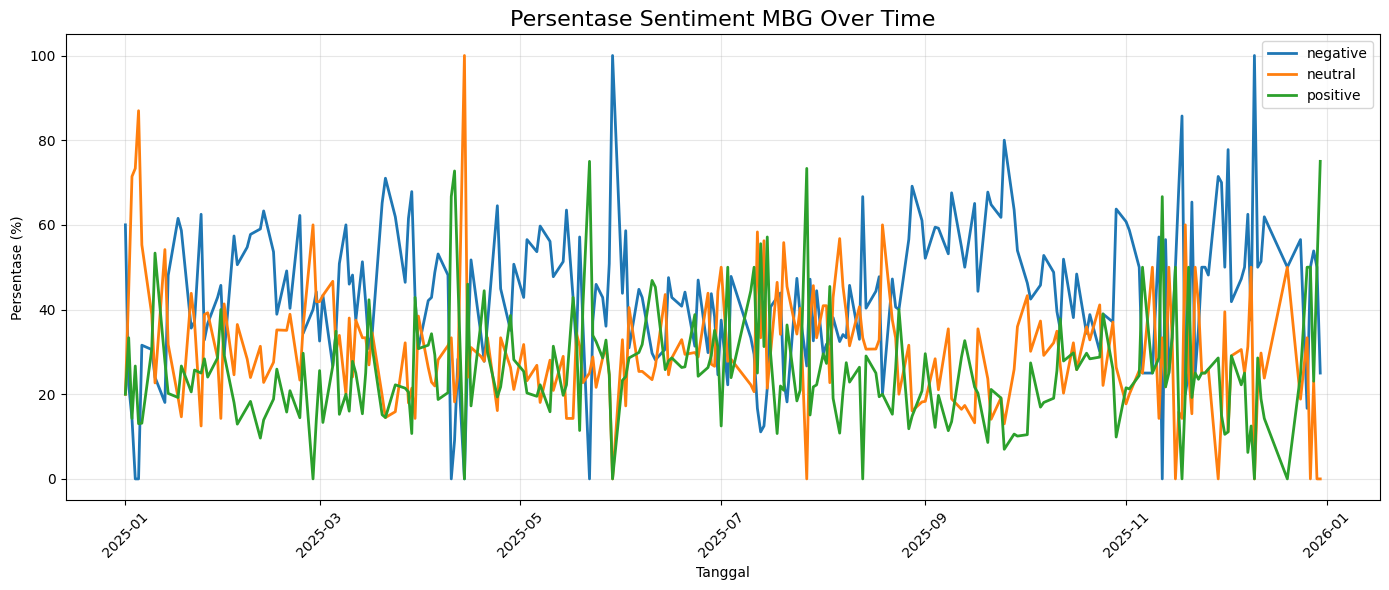

In [ ]:
plt.figure(figsize=(14,6))

for sentiment in daily_percentage.columns:

    plt.plot(
        daily_percentage.index,
        daily_percentage[sentiment],
        label=sentiment,
        linewidth=2
    )

plt.title(
    "Persentase Sentiment MBG Over Time",
    fontsize=16
)

plt.xlabel("Tanggal")
plt.ylabel("Persentase (%)")

plt.legend()

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

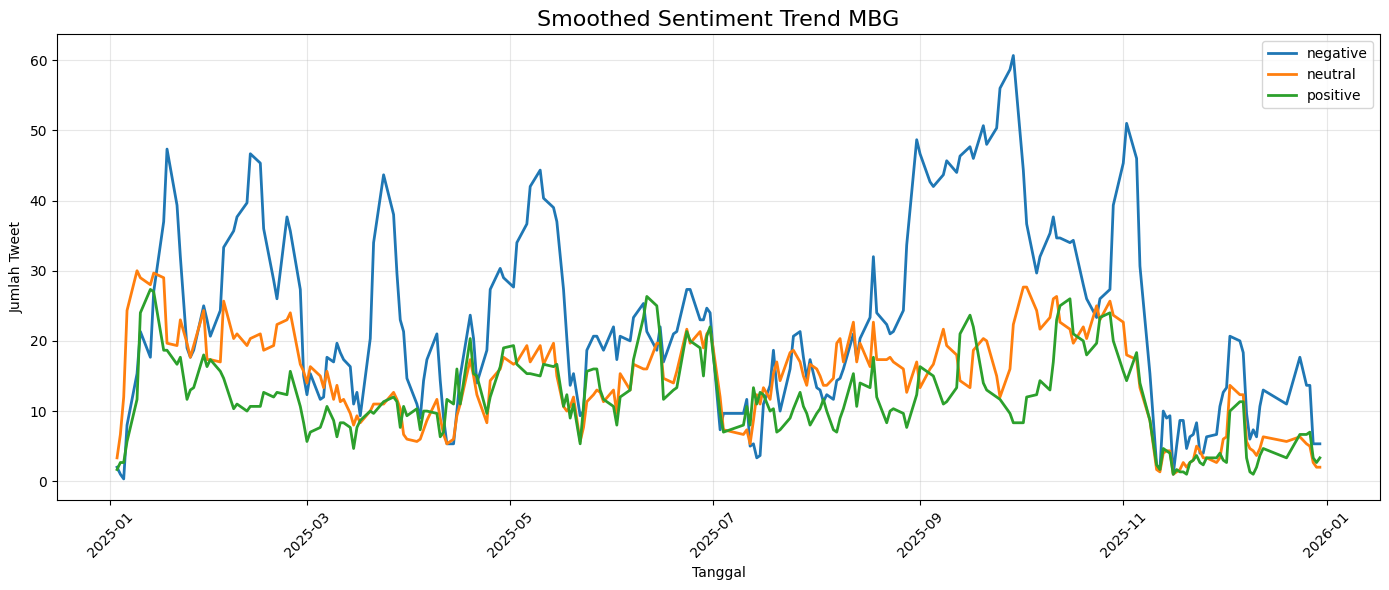

In [ ]:
rolling_sentiment = daily_sentiment.rolling(
    window=3
).mean()

plt.figure(figsize=(14,6))

for sentiment in rolling_sentiment.columns:

    plt.plot(
        rolling_sentiment.index,
        rolling_sentiment[sentiment],
        label=sentiment,
        linewidth=2
    )

plt.title(
    "Smoothed Sentiment Trend MBG",
    fontsize=16
)

plt.xlabel("Tanggal")
plt.ylabel("Jumlah Tweet")

plt.legend()

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
network_df = analysis_df[
    [
        'username',
        'mentions',
        'sentiment'
    ]
].copy()


network_df['mentions_clean'] = df['mentions_clean']

network_df.head()

,username,mentions,sentiment,mentions_clean
0,arinadotid,[],neutral,[]
1,ArifaNidya,[],positive,[]
2,ZainAris,"[{""name"":""Lambe Waras"",""user_id"":""2905814730"",...",negative,"[abu_waras, prabowo]"
3,hereseans,"[{""name"":""Tanyarl 💚"",""user_id"":""13316505595189...",neutral,[tanyakanrl]
4,revirevii1,[],positive,[]


In [ ]:
network_df['community'] = network_df[
    'username'
].map(partition)

network_df = network_df.dropna(
    subset=['community']
)

network_df.head()

,username,mentions,sentiment,mentions_clean,community
2,ZainAris,"[{""name"":""Lambe Waras"",""user_id"":""2905814730"",...",negative,"[abu_waras, prabowo]",0.0
3,hereseans,"[{""name"":""Tanyarl 💚"",""user_id"":""13316505595189...",neutral,[tanyakanrl],22.0
6,MoccaBottol,[],positive,[],165.0
8,Dayak2018,"[{""name"":""Habieb Selow"",""user_id"":""55200751"",""...",neutral,"[wagimandeep212_, prabowo]",2.0
9,hsbhekti,"[{""name"":""SigitS 💚💙❤👍"",""user_id"":""83547693"",""...",negative,"[ssrieyono, yusuf_dumdum, prabowo]",3.0


In [ ]:
community_sizes = network_df[
    'community'
].value_counts()

community_sizes.head(10)

,count
community,
3.0,344
0.0,312
9.0,303
24.0,288
25.0,191
19.0,184
14.0,168
11.0,159
26.0,132


In [ ]:
top_communities = community_sizes.head(10).index

filtered_network_df = network_df[
    network_df['community'].isin(
        top_communities
    )
]

filtered_network_df.head()

,username,mentions,sentiment,mentions_clean,community
2,ZainAris,"[{""name"":""Lambe Waras"",""user_id"":""2905814730"",...",negative,"[abu_waras, prabowo]",0.0
9,hsbhekti,"[{""name"":""SigitS 💚💙❤👍"",""user_id"":""83547693"",""...",negative,"[ssrieyono, yusuf_dumdum, prabowo]",3.0
13,Harian_Jogja,[],neutral,[],11.0
24,SriEry1,"[{""name"":""Mas Veel"",""user_id"":""170912317545028...",negative,"[mas_veel, jokowi, prabowo, gibran_tweet]",10.0
25,G0LIATH87,"[{""name"":""Ahya Nudin"",""user_id"":""1891697324176...",negative,[ahyanudin38985],10.0


In [ ]:
community_sentiment = pd.crosstab(
    filtered_network_df['community'],
    filtered_network_df['sentiment']
)

community_sentiment

sentiment,negative,neutral,positive
community,,,
0.0,183,72,57
3.0,156,125,63
9.0,165,56,82
10.0,60,37,25
11.0,84,49,26
14.0,109,23,36
19.0,71,47,66
24.0,167,53,68
25.0,102,68,21


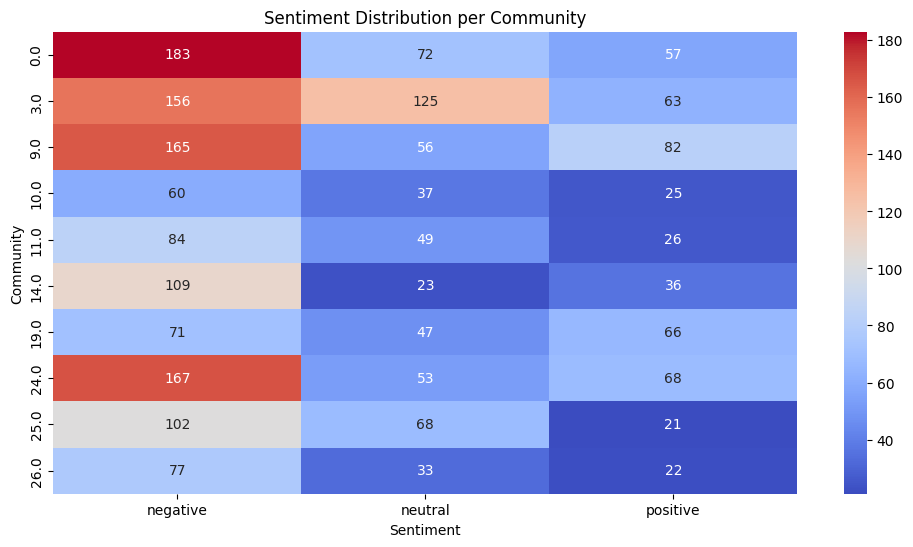

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    community_sentiment,
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title(
    "Sentiment Distribution per Community"
)

plt.xlabel("Sentiment")
plt.ylabel("Community")

plt.show()

In [ ]:
top_communities= top_communities.tolist()
top_communities

[3.0, 0.0, 9.0, 24.0, 25.0, 19.0, 14.0, 11.0, 26.0, 10.0]

In [ ]:
filtered_network_df = filtered_network_df.merge(
    analysis_df[['topic_text']],
    left_index=True,
    right_index=True,
    how='left'
)

filtered_network_df['tokens_topic'] = filtered_network_df[
    'topic_text'
].apply(tokenize_text)

filtered_network_df.head()

,username,mentions,sentiment,mentions_clean,community,topic_text,tokens_topic
2,ZainAris,"[{""name"":""Lambe Waras"",""user_id"":""2905814730"",...",negative,"[abu_waras, prabowo]",0.0,sdh pertengahan januari skrg blm list disekola...,"[sdh, pertengahan, januari, skrg, blm, list, d..."
9,hsbhekti,"[{""name"":""SigitS 💚💙❤👍"",""user_id"":""83547693"",""...",negative,"[ssrieyono, yusuf_dumdum, prabowo]",3.0,puasa libur efisiensi,"[puasa, libur, efisiensi]"
13,Harian_Jogja,[],neutral,[],11.0,bantul bebas keracunan siswa keluhkan makanan ...,"[bantul, bebas, keracunan, siswa, keluhkan, ma..."
24,SriEry1,"[{""name"":""Mas Veel"",""user_id"":""170912317545028...",negative,"[mas_veel, jokowi, prabowo, gibran_tweet]",10.0,buzzer membahas gratismalu liat bentuk liat aj...,"[buzzer, membahas, gratismalu, liat, bentuk, l..."
25,G0LIATH87,"[{""name"":""Ahya Nudin"",""user_id"":""1891697324176...",negative,[ahyanudin38985],10.0,keracunan keracunan persentasenya china india ...,"[keracunan, keracunan, persentasenya, china, i..."


In [ ]:
NUM_TOPICS = 3
NUM_WORDS = 10

community_topic_results = []

for community_id in top_communities:

    print(f"COMMUNITY {community_id}")

    community_df = filtered_network_df[
        filtered_network_df['community']
        == community_id
    ].copy()

    texts = community_df[
        'tokens_topic'
    ].tolist()

    if len(texts) < 20:

        print("Data terlalu sedikit")
        continue

    dictionary = corpora.Dictionary(
        texts
    )

    dictionary.filter_extremes(
        no_below=5,
        no_above=0.5
    )

    corpus = [
        dictionary.doc2bow(text)
        for text in texts
    ]

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=NUM_TOPICS,
        random_state=42,
        passes=15,
        alpha='auto'
    )

    topics = lda_model.print_topics(
        num_words=NUM_WORDS
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_score = (coherence_model.get_coherence())
    print(f"Coherence Score: {round(coherence_score,3)}")

    for topic_num, topic_words in topics:

        print(f"\nTopic {topic_num}")
        print(topic_words)

        # save hasil
        community_topic_results.append({

            'community': community_id,
            'topic': topic_num,
            'keywords': topic_words

        })

    print("\n")

COMMUNITY 3.0
Coherence Score: 0.409

Topic 0
0.051*"makanan" + 0.051*"negara" + 0.044*"keracunan" + 0.036*"sekolah" + 0.034*"indonesia" + 0.026*"gizi" + 0.025*"pemerintah" + 0.021*"siswa" + 0.021*"rakyat" + 0.020*"rumah"

Topic 1
0.033*"juta" + 0.031*"korupsi" + 0.026*"lapangan" + 0.025*"bgn" + 0.021*"ekonomi" + 0.021*"lokal" + 0.020*"gizi" + 0.020*"prabowo" + 0.019*"kerja" + 0.018*"pake"

Topic 2
0.048*"prabowo" + 0.040*"pemerintah" + 0.035*"berdasarkan" + 0.034*"dana" + 0.032*"indonesia" + 0.030*"sumber" + 0.029*"anggaran" + 0.025*"presiden" + 0.021*"keracunan" + 0.019*"siswa"


COMMUNITY 0.0
Coherence Score: 0.409

Topic 0
0.095*"keracunan" + 0.069*"dapur" + 0.054*"dgn" + 0.053*"sekolah" + 0.049*"pendidikan" + 0.042*"korban" + 0.038*"mending" + 0.030*"coba" + 0.029*"suruh" + 0.027*"korupsi"

Topic 1
0.090*"presiden" + 0.067*"indonesia" + 0.062*"keracunan" + 0.061*"siswa" + 0.051*"gizi" + 0.038*"negara" + 0.030*"prabowo" + 0.029*"nasional" + 0.028*"kepala" + 0.027*"anggaran"

Topic 

In [ ]:
topic_results_df = pd.DataFrame(
    community_topic_results
)

topic_results_df.head()

,community,topic,keywords
0,3.0,0,"0.051*""makanan"" + 0.051*""negara"" + 0.044*""kera..."
1,3.0,1,"0.033*""juta"" + 0.031*""korupsi"" + 0.026*""lapang..."
2,3.0,2,"0.048*""prabowo"" + 0.040*""pemerintah"" + 0.035*""..."
3,0.0,0,"0.095*""keracunan"" + 0.069*""dapur"" + 0.054*""dgn..."
4,0.0,1,"0.090*""presiden"" + 0.067*""indonesia"" + 0.062*""..."


In [ ]:
def extract_keywords(topic_string):

    words = []

    topics = topic_string.split("+")

    for topic in topics:

        word = topic.split("*")[1]

        word = word.replace('"', '').strip()

        words.append(word)

    return ", ".join(words)

In [ ]:
topic_results_df['clean_keywords'] = (
    topic_results_df['keywords']
    .apply(extract_keywords)
)

topic_results_df[['community', 'clean_keywords']]

,community,clean_keywords
0,3.0,"makanan, negara, keracunan, sekolah, indonesia..."
1,3.0,"juta, korupsi, lapangan, bgn, ekonomi, lokal, ..."
2,3.0,"prabowo, pemerintah, berdasarkan, dana, indone..."
3,0.0,"keracunan, dapur, dgn, sekolah, pendidikan, ko..."
4,0.0,"presiden, indonesia, keracunan, siswa, gizi, n..."
5,0.0,"rakyat, sekolah, pemerintah, pajak, kerja, bap..."
6,9.0,"dukung, anggaran, negara, indonesia, uang, sam..."
7,9.0,"pemerintah, gimana, kerja, pake, tau, dana, se..."
8,9.0,"lanjutkan, gizi, keracunan, semoga, anakanak, ..."
9,24.0,"keracunan, sekolah, makanan, siswa, pendidikan..."


### Clustering with LDA

In [ ]:
# LDA Global
NUM_TOPICS = 3

texts = (
    df['topic_text']
    .str.split()
    .tolist()
)

dictionary = corpora.Dictionary(
    texts
)

dictionary.filter_extremes(
    no_below=5,
    no_above=0.5
)

corpus = [
    dictionary.doc2bow(text)
    for text in texts
]

lda_model_global = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=15,
    alpha='auto'
)

for topic_num, topic_words in lda_model_global.print_topics(num_words=10):
    print(f"\nTopic {topic_num}")
    print(topic_words)


Topic 0
0.017*"dapur" + 0.016*"kerja" + 0.015*"bgn" + 0.015*"ekonomi" + 0.014*"prabowo" + 0.013*"presiden" + 0.013*"pendidikan" + 0.011*"pemerintah" + 0.010*"sppg" + 0.009*"daerah"

Topic 1
0.019*"keracunan" + 0.019*"sekolah" + 0.012*"makanan" + 0.009*"rakyat" + 0.009*"negara" + 0.008*"menu" + 0.008*"siswa" + 0.006*"anggaran" + 0.006*"biar" + 0.005*"duit"

Topic 2
0.044*"gizi" + 0.042*"indonesia" + 0.030*"makanbergizigratis" + 0.023*"sehat" + 0.021*"anakanak" + 0.020*"generasi" + 0.018*"dukung" + 0.013*"bangsa" + 0.011*"papua" + 0.011*"lanjutkan"


In [ ]:
topic_vectors = []

for doc in corpus:

    topic_prob = lda_model_global.get_document_topics(
        doc,
        minimum_probability=0
    )

    topic_vectors.append(
        [
            prob
            for _, prob
            in topic_prob
        ]
    )

topic_df = pd.DataFrame(
    topic_vectors,
    columns=[
        f'Topic_{i}'
        for i in range(NUM_TOPICS)
    ]
)

topic_df.head()

,Topic_0,Topic_1,Topic_2
0,0.715052,0.109080,0.175868
1,0.062588,0.107432,0.829980
2,0.105982,0.597152,0.296866
3,0.276260,0.488074,0.235666
4,0.287898,0.184658,0.527444


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(topic_df)

    score = silhouette_score(topic_df, labels)

    scores.append(score)

    print(f"K={k} | Score={score:.3f}")

K=2 | Score=0.509
K=3 | Score=0.573
K=4 | Score=0.507
K=5 | Score=0.505
K=6 | Score=0.506
K=7 | Score=0.464
K=8 | Score=0.469
K=9 | Score=0.456
K=10 | Score=0.477


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

topic_df['cluster'] = kmeans.fit_predict(
    topic_df
)

topic_df['cluster'].value_counts()

,count
cluster,
0,6060
2,2662
1,1839


In [ ]:
df['cluster'] = topic_df['cluster']

for cluster_id in sorted(df['cluster'].unique()):

    print(f"\nCLUSTER {cluster_id}")

    texts = (df[df['cluster']==cluster_id]['topic_text'])

    words = " ".join(texts).split()

    freq = pd.Series(words).value_counts()

    print(freq.head(10))


CLUSTER 0
keracunan     626
sekolah       591
makanan       372
rakyat        336
negara        319
menu          258
anggaran      252
siswa         246
pemerintah    224
duit          174
Name: count, dtype: int64

CLUSTER 1
gizi                  482
indonesia             466
makanbergizigratis    455
sehat                 307
generasi              299
anakanak              283
dukung                237
dukungmbg             191
bangsa                159
papua                 149
Name: count, dtype: int64

CLUSTER 2
dapur         259
prabowo       245
bgn           236
pemerintah    229
kerja         228
gizi          222
ekonomi       218
presiden      195
anggaran      181
indonesia     164
Name: count, dtype: int64


In [ ]:
df['sentiment'] = analysis_df['sentiment'].values
df['sentiment_score'] = analysis_df['sentiment_score'].values
cluster_sentiment = pd.crosstab(
    df['cluster'],
    df['sentiment'],
    normalize='index'
) * 100

cluster_sentiment.round(2)

sentiment,negative,neutral,positive
cluster,,,
0,65.87,20.25,13.88
1,9.62,34.37,56.01
2,26.63,47.71,25.66


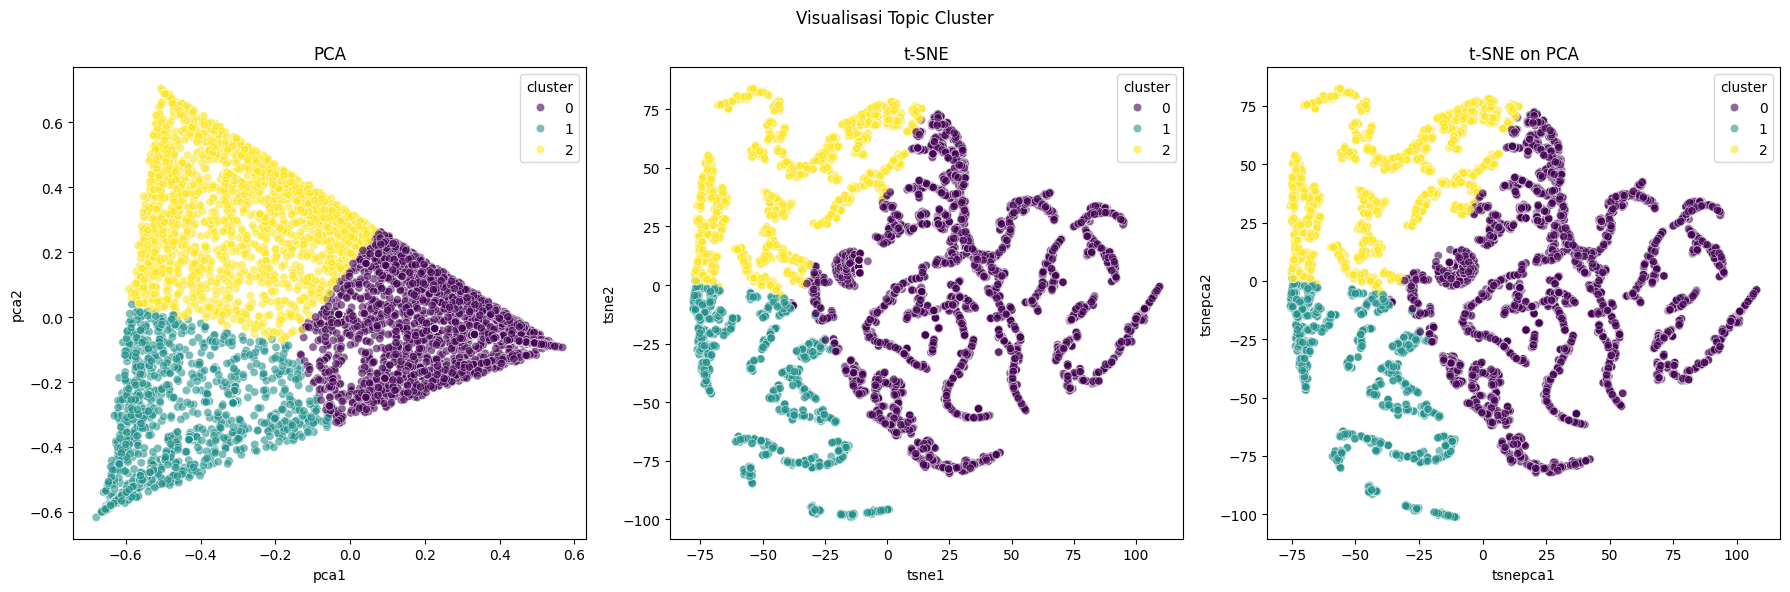

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

features = topic_df.drop('cluster', axis=1)

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(features)

pca50 = PCA(n_components=min(5, features.shape[1]), random_state=42)
pca50_result = pca50.fit_transform(features)

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(features)

tsne_pca = TSNE(n_components=2, random_state=42)
tsne_pca_result = tsne_pca.fit_transform(pca50_result)

plot_df = pd.DataFrame({
    'pca1': pca_result[:,0],
    'pca2': pca_result[:,1],
    'tsne1': tsne_result[:,0],
    'tsne2': tsne_result[:,1],
    'tsnepca1': tsne_pca_result[:,0],
    'tsnepca2': tsne_pca_result[:,1],
    'cluster': topic_df['cluster']
})

fig, axes = plt.subplots(1,3, figsize=(18,6))

sns.scatterplot(data=plot_df, x='pca1', y='pca2', hue='cluster', palette='viridis', alpha=0.6, ax=axes[0], legend=True)
axes[0].set_title("PCA")

sns.scatterplot(data=plot_df, x='tsne1', y='tsne2', hue='cluster', palette='viridis', alpha=0.6, ax=axes[1], legend=True)
axes[1].set_title("t-SNE")

sns.scatterplot(data=plot_df, x='tsnepca1', y='tsnepca2', hue='cluster', palette='viridis', alpha=0.6, ax=axes[2], legend=True)
axes[2].set_title("t-SNE on PCA")

plt.suptitle("Visualisasi Topic Cluster")

plt.tight_layout()

plt.show()

In [ ]:
cluster_summary = df.groupby(
    'cluster'
).agg({
    'sentiment':'value_counts'
})

cluster_summary

sentiment
cluster sentiment           
0       negative        3992
        neutral         1227
        positive         841
1       positive        1030
        neutral          632
        negative         177
2       neutral         1270
        negative         709
        positive         683

In [ ]:
df['major_topic'] = topic_df.drop(
    'cluster',
    axis=1
).idxmax(axis=1)

cluster_topic = pd.crosstab(
    df['cluster'],
    df['major_topic'],
    normalize='index'
) * 100

cluster_topic.round(2)

major_topic,Topic_0,Topic_1,Topic_2
cluster,,,
0,0.00,100.00,0.00
1,0.00,1.63,98.37
2,82.53,15.14,2.33


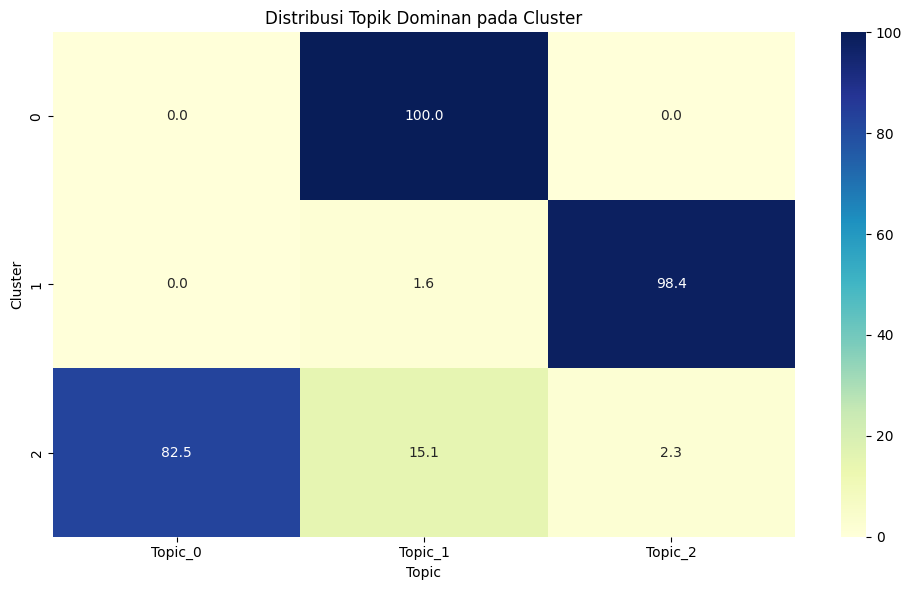

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_topic,
    annot=True,
    cmap='YlGnBu',
    fmt='.1f'
)

setup_plot(
    "Distribusi Topik Dominan pada Cluster",
    "Topic",
    "Cluster"
)

plt.show()